## Satellite Image Classifier

**Author:** Jameson Gormley  
**Dataset:** EuroSAT Satellite Imagery Dataset  
**Data Source:** https://www.kaggle.com/datasets/apollo2506/eurosat-dataset  
**Date Started:** 23 June 2026  
**Status:** In Progress

## Project Overview

The following project develops a Convolutional Neural Network (CNN) from scratch using PyTorch to classify satellite images into multiple land-use categories contained within the EuroSAT dataset.

The objective is to investigate the end-to-end machine learning workflow, including:

- Image preprocessing and transformations with torchvision
- CNN architecture design and implementation with PyTorch
- Model training and validation
- Performance analysis and hyperparameter tuning
- Evaluation on previously unseen test data

## Useful Resources

CNN Theory & Implementation
- Building a CNN Blog: https://medium.com/@foxmike/cnn-for-image-classification-4d655c26b487  
- CNN Visualisation: https://youtu.be/pj9-rr1wDhM?si=O2RjuZTOtdtilI0M
- PyTorch Documentation: https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html  

In [ ]:
import kagglehub

path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

In [2]:
# formatting the source data into train, test, validation
import splitfolders

input_folder = 'dataset'
output_folder = 'split_dataset'

splitfolders.ratio(
    input_folder, 
    output=output_folder, 
    seed=1337, 
    ratio=(0.8, 0.1, 0.1), 
    group_prefix=None
)

In [2]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# creating a transformation pipeline for the input data that resizes images, formats them as an n dimensional array, and then normalises the values
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(torch.Tensor(mean), torch.Tensor(std))
])

train_data = datasets.ImageFolder("split_dataset/train", transform=transform)
val_data   = datasets.ImageFolder("split_dataset/val", transform=transform)
test_data  = datasets.ImageFolder("split_dataset/test", transform=transform)

In [3]:
train_loader = DataLoader(train_data, batch_size=6, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=6, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=6, shuffle=False)

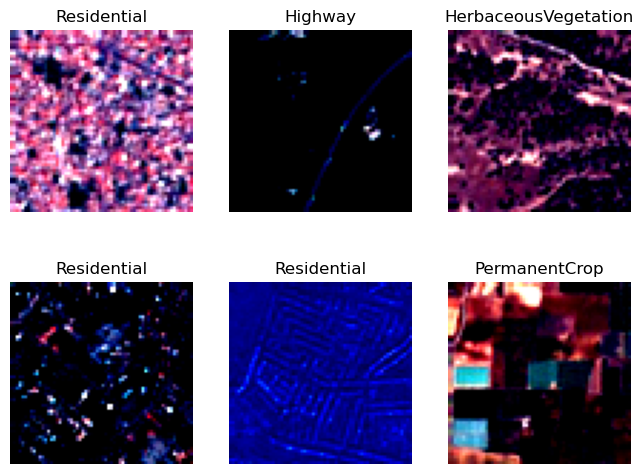

In [4]:
import matplotlib.pyplot as plt
import torchvision.utils as utils
import numpy as np

def display_images(loader):
    images, labels = next(iter(loader))
    class_names = train_data.classes

    fig, axes = plt.subplots(2, 3, figsize=(8, 6))
    axes = axes.flatten()

    for i in range(6):
        img = images[i].permute(1, 2, 0).numpy()

        axes[i].imshow(np.clip(img,0,1))
        axes[i].set_title(class_names[labels[i]])
        axes[i].axis("off")

    plt.show()

# visualisation of sample images being parsed to the CNN 
display_images(train_loader)

In [5]:
# implementing the architecture of the CNN module using PyTorch modules
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # class torch.nn.Conv2d(in_channels, out_channels, kernel_size)
        # class torch.nn.MaxPool2d(kernel_size)
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.pool = nn.MaxPool2d(2)
        # class torch.nn.Linear(in_features, out_features)
        self.fc1 = nn.Linear(13 * 13 * 16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # output dimensions = input dimensions - kernel size + 1 
        
        # input to conv1 is [6,3, 64, 64], output is [6, 6, 60, 60] further halved by pooling [6, 6, 30, 30]
        x = self.pool(F.relu(self.conv1(x)))

        # input to conv2 is [6, 6, 30, 30], output is [6, 16 (output channels), 26, 26] further halved by pooling [6, 16, 13, 13]
        x = self.pool(F.relu(self.conv2(x)))

        # transforms input into a n x 1 vector
        # hence 13 x 13 x 16 output channels
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # output dimensions of linear transformation 3 must match the number of classes as these are the logits used in cross entropy loss calculation
        x = self.fc3(x)
        return x

net = Net()

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = net.to(device)

import torch.optim as optim


# loss will be measured using Cross Entropy function, which in PyTorch first applies a softmax activation function to the ouputs of the network
# each giving them a probability of the image belonging to that class
# cross entropy is then calculated which takes the sum of negative log of each probability for all classes
criterion = nn.CrossEntropyLoss()
optimiser = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

## Initial Training Phase

In [7]:
for epoch in range(5):

    net.train()
    running_loss = 0
    
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        
        # clear the gradients from previous epoch
        optimiser.zero_grad()

        # complete the forward pass
        output = net(inputs)

        # forward loss computation
        loss = criterion(output, labels)

        # take a stochastic batch of data points and uses their gradient wrt loss to optimise incrementally (stochastic gradient descent)
        loss.backward()
        optimiser.step()

        running_loss += loss.item()

    net.eval()

    val_loss = 0

    with torch.no_grad():
        for data in val_loader:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = net(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
        
    print("Epoch:", epoch+1,
          "Train Loss:", running_loss/len(train_loader),
          "Val Loss:", val_loss/len(val_loader))

print("Finished training")

Epoch: 1 Train Loss: 1.5418757173750135 Val Loss: 1.2047253521283467
Epoch: 2 Train Loss: 1.0453660362441506 Val Loss: 0.9057538629219763
Epoch: 3 Train Loss: 0.8510848144452191 Val Loss: 0.7469195742951706
Epoch: 4 Train Loss: 0.6880671499033149 Val Loss: 0.789545830655843
Epoch: 5 Train Loss: 0.5811757575214141 Val Loss: 0.709537801508947
Finished training


## Analysis

In the intial training phase the model shows a consistent decrease in training loss across 5 epochs indicating that it is successfully learning patterns within the training dataset. However, validation loss decreases at a slower rate and shows instability across epochs, especially between epoch 3 to 4 where the validation loss increaces by 4%, suggesting that the model's ability to generalise to unseen data is weaker than its performance on the training set. 

This indicates potential signs of overfitting or limited generalisation capacity in the baseline CNN architecture. Hence, further experimentation will be conducted to improve the model's generalisation ability on unseen validation data. 

## Experiment 1: Dropout Regularisation

The baseline CNN is likely beginning to overfit the training data, as indicated by a faster decrease in training loss compared to validation loss, hence adding dropout should reduce overfitting by randomly deactivating neurons during training, forcing the model to learn more robust features and improving validation performance.